In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os,re,sys

In [24]:
data_dir = r"D:\yhu39\project\sctProt\data"
data_path = os.path.join(data_dir, "LMD_PancreaticCancer_Quant_Spectranout_RAW.xlsx")

In [25]:
data = pd.read_excel(data_path, header=0)

In [26]:
data = data[pd.notna(data['PG.Genes'])]

In [27]:
data["Gene"] = [i.split(";")[0] for i in data["PG.Genes"]]
data = data.drop(["PG.ProteinAccessions","PG.Genes","PG.ProteinDescriptions"],axis=1)
data = data.set_index("Gene")

In [28]:
data

,400_PDAC_1,400_PDAC_2,400_PDAC_3,400_PDAC_4,400_PDAC_5,400_PDAC_6,400_PDAC_7,400_PDAC_8,008_PDAC_1,008_PDAC_2,...,628_IPMN_3,400_NAT_1,400_NAT_2,400_NAT_3,175_NAT_1,175_NAT_2,175_NAT_3,504_NAT_1,504_NAT_2,504_NAT_3
Gene,,,,,,,,,,,,,,,,,,,,,
TMA7B,127.5270,167.1370,462.9640,NaN,316.4950,284.534,493.3610,190.9100,268.0540,NaN,...,589.0530,403.9010,229.986,142.357,NaN,73.4139,47.8911,371.5270,434.3200,234.3330
NUDT4B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,488.6970,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IGLV3-10,159.8200,22.5660,155.6250,NaN,399.0910,232.923,350.5680,44.6435,358.5900,457.1310,...,268.8920,NaN,NaN,310.439,369.0260,141.4840,154.7230,291.6200,276.4840,139.6930
IGKV2-28,95.5461,91.5168,256.8620,45.2649,269.7410,147.210,275.0920,169.5430,230.0110,303.8310,...,177.4630,NaN,382.147,367.669,307.3380,209.3570,303.5880,173.3000,180.3070,125.6430
IGKV2D-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7429.4400,...,3505.3700,NaN,NaN,NaN,NaN,5074.1600,NaN,NaN,979.6070,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FAM169A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,507.1540,458.0390,...,144.3210,222.4600,206.154,NaN,NaN,367.4120,NaN,125.9380,129.1430,NaN
ENPP4,68.4287,25.5968,13.3011,38.7356,91.2990,146.850,91.8063,28.4301,146.9760,238.3930,...,128.2260,246.5380,185.280,290.073,289.6520,61.7974,124.0260,78.5341,85.8978,40.6144
MORC2,NaN,NaN,NaN,22.7497,72.7036,NaN,65.1899,NaN,81.3155,79.5963,...,80.3143,83.7377,116.158,109.258,89.5202,30.0201,194.7050,NaN,NaN,38.2072


In [29]:
data2 = data.map(np.log2)

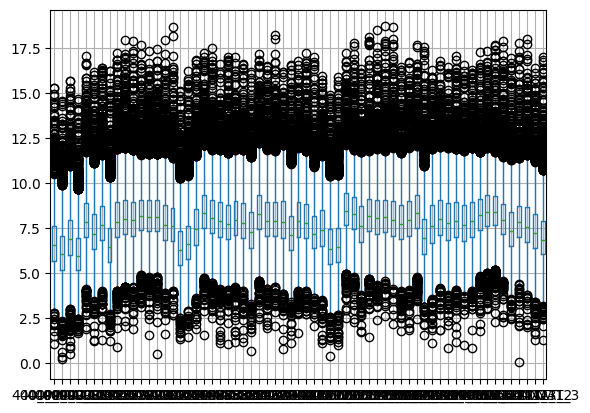

In [30]:
data2.boxplot()
plt.show()

In [31]:
f = data2.median().median()

In [32]:
x = f - data2.median() 

In [33]:
data3 = data2 + x

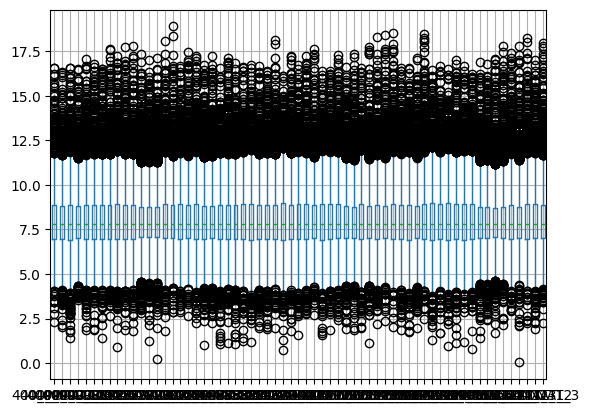

In [34]:
data3.boxplot()
plt.show()

In [35]:
data4 = data3[~data3.index.duplicated(keep='first')]

In [36]:
data4.min().min()

0.032408356310340086

In [37]:
data4.to_csv(os.path.join(data_dir, "LMD_PancreaticCancer_Quant_Spectranout_RAW_log2.tsv"),sep="\t")

In [38]:
os.path.join(data_dir, "LMD_PancreaticCancer_Quant_Spectranout_RAW_log2.tsv")

'D:\\yhu39\\project\\sctProt\\data\\LMD_PancreaticCancer_Quant_Spectranout_RAW_log2.tsv'

In [39]:
data3.shape, data4.shape

((6970, 63), (6965, 63))

In [40]:
data4

,400_PDAC_1,400_PDAC_2,400_PDAC_3,400_PDAC_4,400_PDAC_5,400_PDAC_6,400_PDAC_7,400_PDAC_8,008_PDAC_1,008_PDAC_2,...,628_IPMN_3,400_NAT_1,400_NAT_2,400_NAT_3,175_NAT_1,175_NAT_2,175_NAT_3,504_NAT_1,504_NAT_2,504_NAT_3
Gene,,,,,,,,,,,,,,,,,,,,,
TMA7B,8.264835,9.161677,9.769124,NaN,8.292375,8.776966,9.069436,8.958881,8.066380,NaN,...,9.144470,8.278367,7.260580,6.562206,NaN,6.667157,5.570932,8.792757,9.371823,8.838369
NUDT4B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.724600,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IGLV3-10,8.590480,6.272868,8.196298,NaN,8.626910,8.488218,8.576487,6.862510,8.486191,8.628267,...,8.013099,NaN,NaN,7.687002,8.413401,7.613671,7.262790,8.443380,8.720260,8.092068
IGKV2-28,7.848301,8.292754,8.919218,7.368016,8.061767,7.826240,8.226707,8.787639,7.845559,8.038928,...,7.413590,NaN,7.993161,7.931100,8.149505,8.178997,8.235217,7.692562,8.103520,7.939139
IGKV2D-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.650841,...,11.717567,NaN,NaN,NaN,NaN,12.778129,NaN,NaN,10.545268,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FAM169A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.986280,8.631130,...,7.115353,7.417912,7.102756,NaN,NaN,8.990431,NaN,7.232004,7.622034,NaN
ENPP4,7.366705,6.454681,4.647842,7.143283,6.498863,7.822708,6.643458,6.211479,7.199437,7.689001,...,6.944761,7.566176,6.948741,7.589108,8.063999,6.418650,6.943745,6.550681,7.033758,6.309872
MORC2,NaN,NaN,NaN,6.375470,6.170291,NaN,6.149513,NaN,6.345458,6.106433,...,6.269801,6.008315,6.275122,6.180431,6.369964,5.377033,7.594392,NaN,NaN,6.221725


In [41]:
min_value = data4.min().min()

In [42]:
data4.replace(np.nan, min_value).to_csv(os.path.join(data_dir, "LMD_PancreaticCancer_Quant_Spectranout_RAW_log2_imputed.tsv"),sep="\t")

In [46]:
sigmtx_path = r"D:\yhu39\project\tumordeconv\sigmtx_Joe2.txt"
sigmtx = pd.read_csv(sigmtx_path,sep="\t")
sigmtx = sigmtx.set_index("gene")
sigmtx

,Acinar,Activated_CD4,B cell,CD4,CD8,Effector_CD8,Endothelial,Epithelial_cancer,Epithelial_normal,Fibroblast,Macrophage,Neutrophil,NK/CTL,Stellate,T cell,Treg cell
gene,,,,,,,,,,,,,,,,
SAMD11,0.750004,0.590601,5.601056,0.340973,0.146205,0.966148,2.270164,0.477592,0.823460,26.920312,0.473353,0.054997,0.000000,2.310216,6.689226,0.660131
NOC2L,27.187637,26.724690,36.870527,39.348262,26.316882,28.984435,41.987993,31.710970,30.756230,34.418251,26.486267,19.963783,33.906221,39.821459,32.108284,28.752386
PLEKHN1,3.375017,5.463058,4.488263,2.250421,8.626089,1.932296,0.944228,11.542770,3.458532,1.294825,1.559914,1.154930,5.383215,0.809767,6.689226,4.400875
HES4,51.187758,3.691255,10.831181,5.591954,2.924098,2.898444,48.014977,83.883601,100.709154,82.386996,20.128272,41.302483,5.383215,243.644456,16.054142,8.655055
ISG15,134.625677,155.032730,120.404155,117.976592,159.217139,119.319258,246.644299,413.042438,238.350487,269.579524,289.573864,223.781363,214.203758,391.593562,201.345699,207.281233
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C21orf58,1.312507,6.348959,2.893261,3.477923,6.286811,7.487646,1.647376,2.059976,1.688093,2.439089,2.646475,0.934943,4.017325,2.572200,2.675690,25.965165
PCNT,5.250026,14.765022,9.050713,13.025161,15.497720,17.390661,8.096249,5.454908,5.146625,5.721319,11.973686,13.364186,15.747913,8.312015,12.709529,19.363852
DIP2A,22.875115,61.422491,13.168045,42.076045,64.330157,70.287255,26.116933,21.060089,15.563393,15.808908,27.207055,37.782698,79.623377,14.028014,35.452897,38.287616


In [47]:
sigmtx2 = sigmtx[~sigmtx.index.duplicated(keep='first')]

In [50]:
sigmtx2.to_csv(os.path.join(r"D:\yhu39\project\tumordeconv\sigmtx_Joe2_nodup.txt"),sep="\t")